# 16 — Pooling korpusów: czy obce zbiory Plutchika dożywiają klasy rzadkie TW?

LogReg + char TF-IDF(3,5) dopasowany na danym train, `class_weight=balanced`, progi na **val TW**, ewaluacja na **test TW**.

1. `TW` — punkt odniesienia
2. `TW+CE` — + recenzje
3. `TW+GO` — + tłumaczony Reddit
4. `TW+CE+GO`
5. `TW+rare(CE,GO)` — tylko wiersze z ≥1 klasą rzadką

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, recall_score
from thesis_lib import optimal_thresholds as opt_thr
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid"); plt.rcParams["savefig.dpi"]=300

EMOTIONS=["radość","smutek","zaufanie","wstręt","strach","gniew","przeczuwanie","zdziwienie"]
RARE=["strach","zaufanie","smutek"]
FREQUENT=[e for e in EMOTIONS if e not in RARE]
RANDOM_STATE=42
PROCESSED_DIR=Path("../data/processed"); RESULTS_DIR=Path("../data/results"); FIGURES_DIR=Path("../figures")

def load(prefix, text_col):
    out={}
    for sp in ["train","val","test"]:
        df=pd.read_csv(PROCESSED_DIR/f"{prefix}_{sp}.csv").reset_index(drop=True)
        df["__text"]=df[text_col].fillna("")
        out[sp]=df
    return out

TW=load("twitteremo","tekst"); CE=load("clarin_emo","tekst"); GO=load("go_emotions","text_pl")
print({k:len(v["train"]) for k,v in {"TW":TW,"CE":CE,"GO":GO}.items()})

{'TW': 28684, 'CE': 6367, 'GO': 34276}


In [2]:
def train_eval(train_texts, y_train):
    """Fit char TF-IDF + OvR LogReg on pooled train; tune thresholds on TW val; eval on TW test."""
    vec=TfidfVectorizer(max_features=50_000,ngram_range=(3,5),analyzer="char_wb",min_df=3,sublinear_tf=True)
    X_tr=vec.fit_transform(train_texts)
    X_va=vec.transform(TW["val"]["__text"]); X_te=vec.transform(TW["test"]["__text"])
    y_va=TW["val"][EMOTIONS].values; y_te=TW["test"][EMOTIONS].values
    clf=OneVsRestClassifier(LogisticRegression(max_iter=1000,C=1.0,class_weight="balanced",
            solver="liblinear",random_state=RANDOM_STATE))
    clf.fit(X_tr,y_train)
    thr=opt_thr(y_va,clf.predict_proba(X_va))
    pred=(clf.predict_proba(X_te)>=thr).astype(int)
    r={"n_train":len(train_texts),
       "f1_macro":f1_score(y_te,pred,average="macro",zero_division=0),
       "f1_micro":f1_score(y_te,pred,average="micro",zero_division=0)}
    per=f1_score(y_te,pred,average=None,zero_division=0)
    rec=recall_score(y_te,pred,average=None,zero_division=0)
    for e,f,rc in zip(EMOTIONS,per,rec):
        r[f"f1_{e}"]=f
        if e in RARE: r[f"recall_{e}"]=rc
    r["f1_frequent_avg"]=np.mean([r[f"f1_{e}"] for e in FREQUENT])
    r["f1_rare_avg"]=np.mean([r[f"f1_{e}"] for e in RARE])
    return r

In [3]:
tw_tr=TW["train"]; ce_tr=CE["train"]; go_tr=GO["train"]
rare_ce=ce_tr[ce_tr[RARE].sum(1)>0]; rare_go=go_tr[go_tr[RARE].sum(1)>0]
print(f"rare rows: CE {len(rare_ce)}, GO {len(rare_go)}")

def pool(*dfs):
    texts=pd.concat([d["__text"] for d in dfs],ignore_index=True)
    y=np.vstack([d[EMOTIONS].values for d in dfs])
    return texts, y

variants={
    "1_TW":            pool(tw_tr),
    "2_TW+CE":         pool(tw_tr,ce_tr),
    "3_TW+GO":         pool(tw_tr,go_tr),
    "4_TW+CE+GO":      pool(tw_tr,ce_tr,go_tr),
    "5_TW+rare(CE,GO)":pool(tw_tr,rare_ce,rare_go),
}
rows=[]
for name,(texts,y) in variants.items():
    print(f"{name} (n={len(texts)}) ...",flush=True)
    r=train_eval(texts,y); r["wariant"]=name; rows.append(r)
res=pd.DataFrame(rows).set_index("wariant")
cols=["n_train","f1_macro","f1_micro","f1_rare_avg","f1_frequent_avg",
      "f1_strach","f1_zaufanie","f1_smutek","recall_strach","recall_zaufanie","recall_smutek"]
res=res[cols]
res.round(3).to_csv(RESULTS_DIR/"data_pooling.csv")
display(res.round(3))

rare rows: CE 4135, GO 6185
1_TW (n=28684) ...


2_TW+CE (n=35051) ...


3_TW+GO (n=62960) ...


4_TW+CE+GO (n=69327) ...


5_TW+rare(CE,GO) (n=39004) ...


,n_train,f1_macro,f1_micro,f1_rare_avg,f1_frequent_avg,f1_strach,f1_zaufanie,f1_smutek,recall_strach,recall_zaufanie,recall_smutek
wariant,,,,,,,,,,,
1_TW,28684,0.474,0.579,0.340,0.554,0.385,0.269,0.366,0.385,0.281,0.388
2_TW+CE,35051,0.444,0.565,0.273,0.547,0.286,0.211,0.322,0.308,0.234,0.358
3_TW+GO,62960,0.413,0.538,0.233,0.520,0.250,0.137,0.312,0.231,0.141,0.299
4_TW+CE+GO,69327,0.395,0.525,0.190,0.519,0.095,0.161,0.312,0.077,0.234,0.328
"5_TW+rare(CE,GO)",39004,0.418,0.554,0.221,0.537,0.200,0.182,0.282,0.154,0.219,0.328


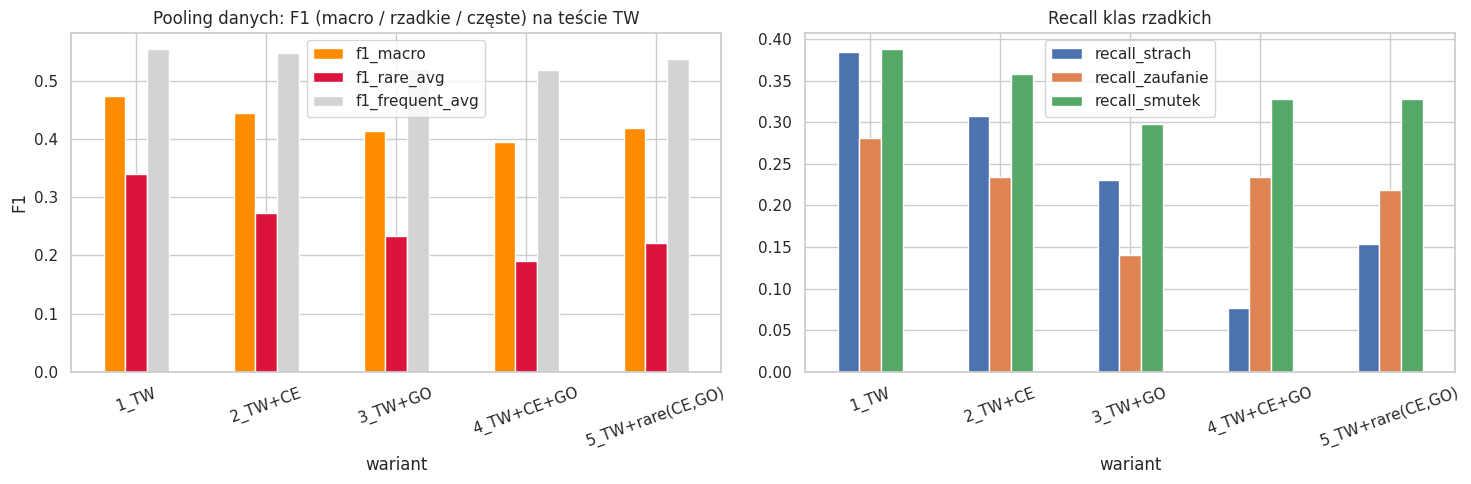

# Pooling danych (16) — wnioski

- Baseline TW: F1-Macro=0.474 (rzadkie 0.340, częste 0.554).
- Najlepszy wariant: **1_TW** = 0.474 (+0.000).
- Wariant celowany (5_TW+rare): macro 0.418, rzadkie 0.221 (baseline 0.340).
- Pelne pooling (4): macro 0.395 przy n=69327.

Interpretacja wzgledem 07 (krzywa nienasycona) i 3x3 (transfer ~0,20): czy obca domena
z ta sama taksonomia substytuuje dane in-domain.



In [4]:
fig,ax=plt.subplots(1,2,figsize=(15,5))
res[["f1_macro","f1_rare_avg","f1_frequent_avg"]].plot(kind="bar",ax=ax[0],
    color=["darkorange","crimson","lightgray"])
ax[0].set_title("Pooling danych: F1 (macro / rzadkie / częste) na teście TW"); ax[0].set_ylabel("F1")
ax[0].tick_params(axis="x",rotation=20)
res[["recall_strach","recall_zaufanie","recall_smutek"]].plot(kind="bar",ax=ax[1])
ax[1].set_title("Recall klas rzadkich"); ax[1].tick_params(axis="x",rotation=20)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"data_pooling.pdf",bbox_inches="tight"); plt.show()
